In [ ]:
"""
Genetic‑Programming FX Strategy — full reference implementation
==============================================================
Replicates the USDJPY exposure strategy described in the “19 % return” paper.
The program is deliberately broken into bite‑sized, helper
functions that you can read, test and swap parts easily.

Workflow outline
----------------
1. Load four CSV files (EURUSD, GBPUSD, AUDUSD, USDJPY) with 5‑minute OHLC.
2. Merge them into a single wide DataFrame.
3. Split into TRAIN / VALID / TEST (out‑of‑sample) according to paper dates.
4. Evolve a Genetic‑Programming tree that outputs the desired position
   percentage in [‑100, +100] using DEAP.
5. Inside the fitness function run backtesting.py on the TRAIN slice *only*.
6. Evaluate top individuals on the VALID slice, pick the best, and finally
   run a pure back‑test on the TEST slice.

You can run the script end‑to‑end (`python gp_fx_gp_strategy.py`) once you
place your CSVs in the same directory.  Expect several hours for a full
75 000×15 run — reduce POP_SIZE / N_GEN while experimenting.

Dependencies
~~~~~~~~~~~~
$ pip install pandas numpy backtesting deap dill matplotlib

The code uses only CPU; parallelism is via `multiprocessing.Pool`.
"""
# from __future__ import annotations

# ─────────────────────────────────────────────────────────────────────────────
# 0. Imports & constants
# ─────────────────────────────────────────────────────────────────────────────
import math
import operator
import random
import time
from pathlib import Path
from typing import Dict, Tuple, List

import dill  # Save / load GP individuals
import numpy as np
import pandas as pd
from backtesting import Backtest, Strategy
from deap import base, creator, gp, tools, algorithms

# Global random seed for reproducibility
RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

# FX symbols to use
PAIRS = ["EURUSD", "GBPUSD", "AUDUSD", "USDJPY"]
# Canonical input order used everywhere (16 names)
ARG_NAMES = [f"{p}_{f}" for p in PAIRS for f in ("Open", "High", "Low", "Close")]

DATA_DIR = Path(".")  # directory containing the CSVs (adjust!)

# Training / validation / test periods (UTC)
TRAIN_START = "2022-07-05 00:00:00"
TRAIN_END   = "2024-01-01 23:55:00"
VAL_START   = "2024-01-02 00:00:00"
VAL_END     = "2024-07-04 23:55:00"
TEST_START  = "2024-07-05 00:00:00"
TEST_END    = "2025-07-05 23:55:00"

# GP hyper‑parameters (paper values)
POP_SIZE = 400 # population size 75K per the paper
N_GEN    = 15
P_CX     = 0.90
P_MUT    = 0.15
MAX_DEPTH = 8 # max tree depth (8 per the paper)
MAX_LEN   = 60  # max number of nodes per tree

# Backtest settings
INITIAL_CASH  = 1_000_000  # USD
COMMISSION_PCT = 0.000015  # 15 $ / 1M
POSITION_GRID  = 5_000     # round target position to nearest 5 000 units
NO_TRADE_BAND  = 10        # ±10 pp dead‑band

# Progress tracking global variables
_evaluation_count = 0
_current_generation = 0
_start_time = None

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. Data handling
# ─────────────────────────────────────────────────────────────────────────────
def _detect_datetime_column(df: pd.DataFrame) -> str:
    """Return the name of the first column that *looks* like a datetime column."""
    for col in df.columns:
        low = col.lower().replace(" ", "")
        if low in {"date", "datetime", "time", "timestamp", "gmttime"}:
            return col
    raise ValueError("No datetime column found. Expected one of Date / Datetime / Gmt time …")

def load_pair_csv(symbol: str, path: Path, freq: str = "5min") -> pd.DataFrame:
    """Load a CSV that has *any* datetime column name (Date, Gmt time, …) and
    resample it to *freq*.  The loader keeps only OHLC columns and renames them
    to <SYMBOL>_<FIELD> so later merging is unambiguous.
    """
    print(f" Loading {symbol} data from {path.name}...")
    df = pd.read_csv(path)

    # 1) Identify & parse the datetime column
    date_col = _detect_datetime_column(df)
    df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, utc=True, errors="coerce")
    df = df.dropna(subset=[date_col])
    df = df.set_index(date_col)

    # 2) Keep OHLC columns (case‑insensitive match) and standardise names
    col_map = {}
    for col in df.columns:
        low = col.lower()
        if low.startswith("open"):
            col_map[col] = "Open"
        elif low.startswith("high"):
            col_map[col] = "High"
        elif low.startswith("low"):
            col_map[col] = "Low"
        elif low.startswith("close"):
            col_map[col] = "Close"
    df = df[list(col_map.keys())].rename(columns=col_map)

    # 3) Resample to 5‑minute bars and forward‑fill gaps
    df = df.resample(freq, label="right", closed="right").agg({
        "Open": "first",
        "High": "max",
        "Low":  "min",
        "Close": "last",
    }).ffill()

    # 4) Prefix columns with the symbol (EURUSD_Open, …)
    df.columns = [f"{symbol}_{c}" for c in df.columns]
    print(f" {symbol}: {len(df)} bars loaded and resampled")
    return df

def load_all_pairs(data_dir: Path, pairs: List[str] = PAIRS) -> pd.DataFrame:
    """Load every CSV into a *wide* DataFrame indexed by timestamp."""
    print(f" Loading {len(pairs)} currency pairs from {data_dir}...")
    dfs = []
    for i, pair in enumerate(pairs):
        csv_path = data_dir / f"{pair}_Candlestick_5_M_BID_05.07.2022-05.07.2025.csv"
        if not csv_path.exists():
            raise FileNotFoundError(csv_path)
        dfs.append(load_pair_csv(pair, csv_path))
        print(f"Progress: {i+1}/{len(pairs)} pairs loaded ({(i+1)/len(pairs)*100:.1f}%)")
    
    print("🔗 Merging all pairs into unified dataset...")
    combined = pd.concat(dfs, axis=1).dropna()
    print(f" Dataset merged: {len(combined)} synchronized bars across all pairs")
    return combined

def split_dataset(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Return (train, validation, test) slices according to constants."""
    print(" Splitting dataset into train/validation/test periods...")
    train = df.loc[TRAIN_START:TRAIN_END].copy()
    val   = df.loc[VAL_START:VAL_END].copy()
    test  = df.loc[TEST_START:TEST_END].copy()
    
    print(f" Training set: {len(train)} bars ({TRAIN_START} to {TRAIN_END})")
    print(f" Validation set: {len(val)} bars ({VAL_START} to {VAL_END})")
    print(f" Test set: {len(test)} bars ({TEST_START} to {TEST_END})")
    
    return train, val, test

In [5]:
d = load_all_pairs(data_dir=DATA_DIR)
d.isna().sum()
# t, v, tt = split_dataset(d)
# tt

 Loading 4 currency pairs from ....
 Loading EURUSD data from EURUSD_Candlestick_5_M_BID_05.07.2022-05.07.2025.csv...
 EURUSD: 315936 bars loaded and resampled
Progress: 1/4 pairs loaded (25.0%)
 Loading GBPUSD data from GBPUSD_Candlestick_5_M_BID_05.07.2022-05.07.2025.csv...
 GBPUSD: 315648 bars loaded and resampled
Progress: 2/4 pairs loaded (50.0%)
 Loading AUDUSD data from AUDUSD_Candlestick_5_M_BID_05.07.2022-05.07.2025.csv...
 AUDUSD: 315612 bars loaded and resampled
Progress: 3/4 pairs loaded (75.0%)
 Loading USDJPY data from USDJPY_Candlestick_5_M_BID_05.07.2022-05.07.2025.csv...
 USDJPY: 315936 bars loaded and resampled
Progress: 4/4 pairs loaded (100.0%)
🔗 Merging all pairs into unified dataset...
 Dataset merged: 315612 synchronized bars across all pairs


EURUSD_Open     0
EURUSD_High     0
EURUSD_Low      0
EURUSD_Close    0
GBPUSD_Open     0
GBPUSD_High     0
GBPUSD_Low      0
GBPUSD_Close    0
AUDUSD_Open     0
AUDUSD_High     0
AUDUSD_Low      0
AUDUSD_Close    0
USDJPY_Open     0
USDJPY_High     0
USDJPY_Low      0
USDJPY_Close    0
dtype: int64

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. Helper utilities
# ─────────────────────────────────────────────────────────────────────────────
def round_grid(x: float, grid: int = POSITION_GRID) -> int:
    """Round *x* to nearest multiple of *grid* (integer)."""
    return int(round(x / grid) * grid)

def pct_to_units(percent: float, equity: float, price: float) -> float:
    """Convert desired exposure % → raw units at current price."""
    return percent / 100.0 * equity / price

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. backtesting.py Strategy implementation
# ─────────────────────────────────────────────────────────────────────────────
class GPExposureStrategy(Strategy):
    commission, slippage = COMMISSION_PCT, 0.0
    expression = None  # injected callable

    def init(self):
        broker = self._broker
        equity_start = getattr(broker, "equity", getattr(broker, "_equity"))
        cash_half = equity_start/2
        price0 = self.data.Close[0]
        qty = round_grid(cash_half/price0)
        if qty:
            self.buy(size=qty)
            self.sell(size=qty)
        self.current_pct = 0.0

    def next(self):
        # Build input vector in the canonical ARG_NAMES order (16 values)
        
        # **FAST PATH**: assume df.columns exactly == ARG_NAMES in order
        # Grab the last bar and reindex by ARG_NAMES to enforce order
        # row = self.data.df.iloc[-1]
        # inputs = row[ARG_NAMES].to_numpy(dtype=float)

        inputs = []
        for name in ARG_NAMES:
            # Check if the exact column name exists in the dataframe
            if name in self.data.df.columns:
                inputs.append(float(self.data.df[name].iloc[-1]))
            else:
                # Handle USDJPY special case - remove prefix if needed
                alt_name = name.replace("USDJPY_", "")
                if alt_name in self.data.df.columns:
                    inputs.append(float(self.data.df[alt_name].iloc[-1]))
                else:
                    raise RuntimeError(f"Column {name} or {alt_name} not found in dataframe")
                
        #print(" >>>>>>>>>>>>>>>>>>>>>>>>>    ", len(inputs))
        
        # Ensure we have exactly 16 inputs
        if len(inputs) != len(ARG_NAMES):
            raise RuntimeError(f"!!!!!!!!    Expected {len(ARG_NAMES)} inputs, got {len(inputs)}")

        
        # print("lambda expects:", self.expression.__code__.co_argcount)
        # print("inputs given   :", len(inputs))
        # print("columns        :", self.data.df.columns.tolist())   # or whatever slice you use


        #desired = float(GPExposureStrategy.expression(*inputs))
        desired = float(self.expression(*inputs))
        
        if abs(desired - self.current_pct) <= NO_TRADE_BAND: # if the desired exposure is not that different than the current one do nothing
            return

        broker = self._broker
        equity_now = getattr(broker, "equity", getattr(broker, "_equity"))
        price_now  = self.data.Close[-1]
        target = pct_to_units(desired, equity_now, price_now)
        delta  = target - self.position.size
        order  = round_grid(delta)
        if order == 0:
            return
        if order > 0:
            self.buy(size=order)
        else:
            self.sell(size=-order)
        self.current_pct = desired

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. Genetic‑Programming setup (DEAP)
# ─────────────────────────────────────────────────────────────────────────────
print(" Setting up Genetic Programming framework...")

# Define primitive set
pset = gp.PrimitiveSet("FX", 16, prefix="inp")

# Arithmetic ops (avoid div‑by‑zero)
pset.addPrimitive(operator.add, 2)
pset.addPrimitive(operator.sub, 2)
pset.addPrimitive(operator.mul, 2)

def protected_div(a, b):
    return a / b if abs(b) > 1e-8 else a
pset.addPrimitive(protected_div, 2)

# Trig & tanh
pset.addPrimitive(math.sin, 1)
pset.addPrimitive(math.cos, 1)
pset.addPrimitive(math.tan, 1)
pset.addPrimitive(math.tanh, 1)

# Comparison → float (0/100) helper
def greater(a, b):
    return 100.0 if a > b else -100.0
pset.addPrimitive(greater, 2)

# Ephemeral constant
pset.addEphemeralConstant("rand", lambda: random.uniform(-1.0, 1.0))

# Rename arguments for readability
for i, name in enumerate(ARG_NAMES):
    pset.renameArguments(**{f"inp{i}": name})

# Create fitness & individual classes
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))  # minimise exp(‑return)
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=1, max_=MAX_DEPTH)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("compile", gp.compile, pset=pset)

toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("mate", gp.cxOnePoint)

toolbox.register("expr_mut", gp.genFull, min_=0, max_=2)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)

print(" GP framework configured with primitives and operators")

# ───────────── Evaluate fitness via backtesting.py ───────────────────────────

def evaluate_individual(individual, df_train: pd.DataFrame) -> Tuple[float]:
    """Run backtest on TRAIN slice and return exp(‑return) + penalty if needed."""
    global _evaluation_count, _current_generation, _start_time
    _evaluation_count += 1
    
    # Progress reporting every 1000 evaluations
    if _evaluation_count % 100 == 0:
        elapsed = time.time() - _start_time if _start_time else 0
        total_evals = POP_SIZE * N_GEN
        progress = (_evaluation_count / total_evals) * 100
        
        print(f" Generation {_current_generation}: {_evaluation_count:,}/{total_evals:,} evaluations "
              f"({progress:.1f}%) | Time: {elapsed:.1f}s")
    
    try:
        func = toolbox.compile(expr=individual)
        # Attach expression to Strategy
        GPExposureStrategy.expression = func
        try:
            # call with 16 dummy zeros
            _ = func(*([0.0] * len(ARG_NAMES)))
            print(f"🔍 GP function sanity: accepts {len(ARG_NAMES)} inputs ")
        except Exception as e:
            print(f" GP function sanity check FAILED:", e)

        # backtesting.py expects traded instrument columns only.
        # Build USDJPY‑only OHLC plus extras.
        usdjpy = df_train[[c for c in df_train.columns if c.startswith("USDJPY_")]].copy()
        usdjpy.columns = [c.replace("USDJPY_", "") for c in usdjpy.columns]
        # Add other cols
        extras = df_train[[c for c in df_train.columns if not c.startswith("USDJPY_")]]
        usdjpy = usdjpy.join(extras)

        bt = Backtest(usdjpy, GPExposureStrategy,
                      cash=INITIAL_CASH, commission=COMMISSION_PCT,
                      exclusive_orders=False, trade_on_close=True)
        stats = bt.run()

        total_return = stats["Return [%]"] / 100.0  # fraction
        n_trades = stats["# Trades"]
        nav_final = INITIAL_CASH * (1 + total_return)

        # Penalties
        if nav_final <= 0 or n_trades < 50:
            return (1e6,)
        fitness = math.exp(-total_return)
        return (fitness,)
    except Exception as e:
        # Return high penalty for any error
        return (1e6,)

def limit_tree(individual):
    """Operator to discard individuals larger than MAX_LEN nodes."""
    if len(individual) > MAX_LEN:
        return False  # signal invalid
    return True

toolbox.decorate("mate", gp.staticLimit(key=len, max_value=MAX_LEN))
toolbox.decorate("mutate", gp.staticLimit(key=len, max_value=MAX_LEN))


 Setting up Genetic Programming framework...
 GP framework configured with primitives and operators


f:\Python\Lib\site-packages\deap\gp.py:254: RuntimeWarning: Ephemeral rand function cannot be pickled because its generating function is a lambda function. Use functools.partial instead.
  warnings.warn("Ephemeral {name} function cannot be "


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. Main evolutionary loop
# ─────────────────────────────────────────────────────────────────────────────
def custom_ea_simple(population, toolbox, cxpb, mutpb, ngen, stats=None,
                     halloffame=None, verbose=__debug__):
    """Custom evolutionary algorithm with detailed progress reporting."""
    global _current_generation, _start_time
    
    print(f" Starting evolution with {len(population)} individuals for {ngen} generations")
    print(f"  Parameters: CrossOver={cxpb}, Mutation={mutpb}, MaxDepth={MAX_DEPTH}, MaxLen={MAX_LEN}")
    
    _start_time = time.time()
    
    # Evaluate initial population
    print(" Evaluating initial population...")
    fitnesses = toolbox.map(toolbox.evaluate, population)
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit
    
    if halloffame is not None:
        halloffame.update(population)
    
    # Begin evolution
    for gen in range(1, ngen + 1):
        _current_generation = gen
        gen_start_time = time.time()
        
        print(f"\n Generation {gen}/{ngen} starting...")
        
        # Selection
        offspring = toolbox.select(population, len(population))
        offspring = list(map(toolbox.clone, offspring))
        
        # Apply crossover and mutation
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < cxpb:
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values
        
        for mutant in offspring:
            if random.random() < mutpb:
                toolbox.mutate(mutant)
                del mutant.fitness.values
        
        # Evaluate invalid individuals
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        print(f" Evaluating {len(invalid_ind)} new individuals...")
        
        fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit
        
        # Update population
        population[:] = offspring
        
        # Update hall of fame
        if halloffame is not None:
            halloffame.update(population)
        
        # Gather statistics
        if stats is not None:
            record = stats.compile(population)
            
            gen_time = time.time() - gen_start_time
            total_time = time.time() - _start_time
            
            print(f" Generation {gen} complete in {gen_time:.1f}s (Total: {total_time:.1f}s)")
            print(f" Best fitness: {record['fitness']['min']:.6f}")
            print(f" Avg fitness: {record['fitness']['avg']:.6f}")
            print(f" Avg tree size: {record['size']['avg']:.1f} nodes")
            
            if halloffame:
                best_ind = halloffame[0]
                print(f" Hall of Fame leader: fitness={best_ind.fitness.values[0]:.6f}, "
                      f"size={len(best_ind)} nodes")
        
        # Progress estimate
        progress = (gen / ngen) * 100
        estimated_total = total_time * (ngen / gen)
        remaining = estimated_total - total_time
        
        print(f"  Progress: {progress:.1f}% | ETA: {remaining:.1f}s")
    
    return population

def run_evolution(train_df: pd.DataFrame, n_gen=N_GEN, pop_size=POP_SIZE) -> List[creator.Individual]:
    """Evolve and return the hall‑of‑fame individuals (top 10)."""
    toolbox.register("evaluate", evaluate_individual, df_train=train_df)

    print(f" Creating initial population of {pop_size:,} individuals...")
    pop = toolbox.population(n=pop_size)
    hof = tools.HallOfFame(10, similar=lambda a, b: a == b)

    stats_fit = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats_len = tools.Statistics(len)
    mstats = tools.MultiStatistics(fitness=stats_fit, size=stats_len)
    mstats.register("min", np.min)
    mstats.register("avg", np.mean)

    print(" Population created, starting evolution...")
    
    # Use custom EA with progress reporting
    custom_ea_simple(pop, toolbox, cxpb=P_CX, mutpb=P_MUT, ngen=n_gen,
                     stats=mstats, halloffame=hof, verbose=True)

    print(f"\n Evolution complete! Hall of Fame contains {len(hof)} individuals")
    return hof


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. Validation & test evaluation helpers
# ─────────────────────────────────────────────────────────────────────────────
def backtest_on_slice(individual, df_slice, label):
    """Run the strategy encoded by *individual* on *df_slice* and return stats."""
    print(f"\n Running backtest on {label} dataset…")
    
    # 1) compile and attach the GP expression
    func = toolbox.compile(expr=individual)
    #GPExposureStrategy.expression = func
    GPExposureStrategy.expression = staticmethod(func)

    # 2) exactly what you did in the evaluation function
    #    — grab USDJPY_* → rename to Open/High/Low/Close
    usdjpy = df_slice[[c for c in df_slice.columns
                       if c.startswith("USDJPY_")]].copy()
    usdjpy.columns = [c.replace("USDJPY_", "") for c in usdjpy.columns]

    # 3) stick every other column back on as “extras”
    extras = df_slice[[c for c in df_slice.columns
                       if not c.startswith("USDJPY_")]].copy()
    usdjpy = usdjpy.join(extras)

    #print("→ backtesting with columns:", usdjpy.columns.tolist())

    # 4) run the backtest on that combined DataFrame
    bt = Backtest(usdjpy,
                  GPExposureStrategy,
                  cash=INITIAL_CASH,
                  commission=COMMISSION_PCT,
                  exclusive_orders=False,
                  trade_on_close=True)
    stats = bt.run()

    print(f" {label} backtest complete!")
    print(f"===  {label} RESULTS ===")
    print(f" Return: {stats['Return [%]']:.2f}%")
    print(f" Sharpe Ratio: {stats['Sharpe Ratio']:.3f}")
    print(f" Number of Trades: {stats['# Trades']}")
    print(f" Win Rate: {stats['Win Rate [%]']:.1f}%")
    print(f" Final Equity: ${stats['Equity Final [$]']:,.2f}")

    return stats, bt


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# 7. Entry‑point
# ─────────────────────────────────────────────────────────────────────────────

print(" Starting Genetic Programming FX Strategy Evolution")
print("=" * 60)

# 1) Load & split data
print("\n PHASE 1: Data Loading and Preparation")
print("-" * 40)
df_all = load_all_pairs(DATA_DIR)
train_df, val_df, test_df = split_dataset(df_all)

# 2) Register evaluation with global TRAIN slice
print("\n PHASE 2: Genetic Programming Evolution")
print("-" * 40)
toolbox.register("evaluate", evaluate_individual, df_train=train_df)

# 3) Run evolutionary search (this is the long step)
hof = run_evolution(train_df)

# 4) Validation of hall‑of‑fame
print("\n PHASE 3: Validation on Out-of-Sample Data")
print("-" * 40)
print(" Evaluating Hall of Fame individuals on validation set...")

val_scores = []
for i, ind in enumerate(hof):
    print(f" Evaluating individual {i+1}/{len(hof)}...")
    score = evaluate_individual(ind, val_df)[0]
    val_scores.append(score)
    print(f" Individual {i+1} validation score: {score:.6f}")

# Pick best on validation set
idx_best = int(np.argmin(val_scores))
best_ind = hof[idx_best]
print(f"\n Best individual: #{idx_best+1} with validation score: {val_scores[idx_best]:.6f}")
print(f" Best tree size: {len(best_ind)} nodes")

 Starting Genetic Programming FX Strategy Evolution

 PHASE 1: Data Loading and Preparation
----------------------------------------
 Loading 4 currency pairs from ....
 Loading EURUSD data from EURUSD_Candlestick_5_M_BID_05.07.2022-05.07.2025.csv...
 EURUSD: 315936 bars loaded and resampled
Progress: 1/4 pairs loaded (25.0%)
 Loading GBPUSD data from GBPUSD_Candlestick_5_M_BID_05.07.2022-05.07.2025.csv...
 GBPUSD: 315648 bars loaded and resampled
Progress: 2/4 pairs loaded (50.0%)
 Loading AUDUSD data from AUDUSD_Candlestick_5_M_BID_05.07.2022-05.07.2025.csv...
 AUDUSD: 315612 bars loaded and resampled
Progress: 3/4 pairs loaded (75.0%)
 Loading USDJPY data from USDJPY_Candlestick_5_M_BID_05.07.2022-05.07.2025.csv...
 USDJPY: 315936 bars loaded and resampled
Progress: 4/4 pairs loaded (100.0%)
🔗 Merging all pairs into unified dataset...
 Dataset merged: 315612 synchronized bars across all pairs
 Splitting dataset into train/validation/test periods...
 Training set: 157248 bars (2022-0

In [ ]:
# 5) Final back‑test on unseen TEST slice
print("\n PHASE 4: Final Testing on Unseen Data")
print("-" * 40)
stats, bt  = backtest_on_slice(best_ind, test_df.reset_index(), "TEST (Out-of-Sample)")

# 6) Save best individual for later reuse
print("\n PHASE 5: Saving Results")
print("-" * 40)
with open("best_individual.dill", "wb") as f:
    dill.dump(best_ind, f)
print(" Best GP tree saved to best_individual.dill")

print("\n Evolution process completed successfully!")
print("=" * 60)

# Final summary
print("\n SUMMARY")
print(f" Population size: {POP_SIZE:,}")
print(f" Generations: {N_GEN}")
print(f" Best individual: Tree #{idx_best+1} from Hall of Fame")
print(f" Total evaluations: {_evaluation_count:,}")

total_time = time.time() - _start_time if _start_time else 0
print(f"  Total runtime: {total_time:.1f} seconds ({total_time/60:.1f} minutes)")


 PHASE 4: Final Testing on Unseen Data
----------------------------------------

 Running backtest on TEST (Out-of-Sample) dataset…


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_17884\2464624805.py:27: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(usdjpy,


In [13]:
stats

Start                     2024-07-05 00:00...
End                       2025-07-04 20:55...
Duration                    364 days 20:55:00
Exposure Time [%]                   46.530395
Equity Final [$]               1044755.718675
Equity Peak [$]                1070459.842625
Return [%]                           4.476836
Buy & Hold Return [%]              -10.504006
Return (Ann.) [%]                    4.476836
Volatility (Ann.) [%]                5.650956
Sharpe Ratio                         0.792226
Sortino Ratio                        1.242932
Calmar Ratio                         1.297619
Max. Drawdown [%]                   -3.450039
Avg. Drawdown [%]                   -0.211971
Max. Drawdown Duration       79 days 04:05:00
Avg. Drawdown Duration        2 days 15:10:00
# Trades                                  711
Win Rate [%]                        23.347398
Best Trade [%]                       1.931113
Worst Trade [%]                     -0.715236
Avg. Trade [%]                    

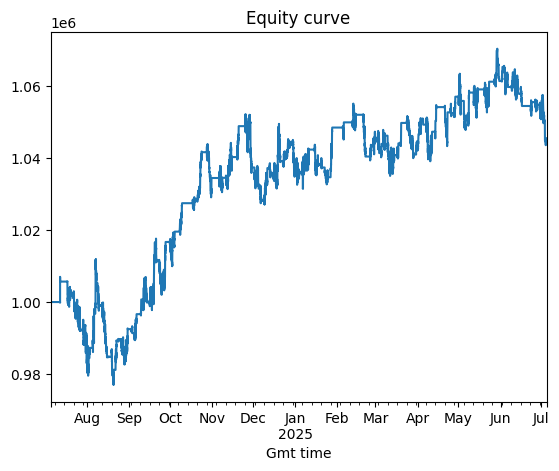

In [14]:
import matplotlib.pyplot as plt
equity = stats['_equity_curve']['Equity']
equity.plot(title="Equity curve")
plt.show()

In [15]:
bt.plot(results=stats)

f:\Python\Lib\site-packages\backtesting\_plotting.py:122: UserWarning: Data contains too many candlesticks to plot; downsampling to '1H'. See `Backtest.plot(resample=...)`
  warnings.warn(f"Data contains too many candlesticks to plot; downsampling to {freq!r}. "
f:\Python\Lib\site-packages\backtesting\_plotting.py:126: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample(freq, label='right').agg(OHLCV_AGG).dropna()
f:\Python\Lib\site-packages\backtesting\_plotting.py:136: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  equity_data = equity_data.resample(freq, label='right').agg(_EQUITY_AGG).dropna(how='all')
f:\Python\Lib\site-packages\backtesting\_plotting.py:153: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  trades = trades.assign(count=1).resample(freq, on='ExitTime', label='right').agg(dict(
f:\Python\Lib\site-pack

ValueError: Length of values (2) does not match length of index (1)